---
title: "Weather-Induced Extremes - Data Access using DEDL HDA"
subtitle: "This notebook demonstrates how to access and download sea ice coverage data from the Weather-Induced Extremes Digital Twin using the DestinE Data Lake Harmonised Data Access (DEDL HDA) API, including authentication, filtering, polling, and visualizing the result on a map."
author: "Michael Schick (EUMETSAT), Serena Avolio (EUMETSAT/Starion)"
tags: [HDA, ECMWF, Digital Twin]
thumbnail: ../../img/ECMWF.png
license: MIT
copyright: "© 2025 EUMETSAT"
---
<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/HDA/DestinE_Digital_Twins/DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b><ul>
   <li>To search and access DEDL data a <a href="https://platform.destine.eu/"> DestinE user account</a> is needed</li>
   <li>To search and access DT data an <a href="https://platform.destine.eu/support-pages/access-policy/"> upgraded access</a> is needed.</li></ul>
<b> References: </b><ul>
    <li><a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Use-of-Harmonized-Data-Access/Use-of-Harmonized-Data-Access.html">DestinE Data Lake (DEDL) Harmonized Data Access (HDA) documentation</a> </li>
    <li> <a href="https://destine.ecmwf.int/weather-induced-extremes-digital-twin-1/">Weather-Induced Extremes Digital Twin (Extremes DT)</a></li>
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/Extremes+DT+data+catalogue">Extreme DT data catalogue</a></li></ul>


# Weather-Induced Extremes DT Parameter - Data Access using DEDL HDA

This notebook demonstrates how to use the **HDA (Harmonized Data Access) API to query and access Extremes DT data** to plot a parameter.
Below the main steps covered by this tutorial.

1. [Setup](#DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Setup): Import the required libraries.
2. [Search](#DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Search): How to search Extremes DT data.
3. [Order and Download](#DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Order-and-Download): How to filter and download Extremes DT data.
4. [Plot](#DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Render-the-sea-ice-coverage-on-a-map): How to visualize sea ice coverage on a map.

(DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Setup)=
# Setup

In [1]:
pip install --user --quiet --upgrade destinelab

Note: you may need to restart the kernel to use updated packages.


Import all the required packages.

In [2]:
import destinelab as deauth
import json
import datetime
import importlib.metadata

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import os
from getpass import getpass
from tqdm import tqdm
import time
from datetime import datetime, timedelta
from urllib.parse import unquote
from IPython.display import JSON
import ipywidgets as widgets

(DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES-Series.ipynb-Search)=

# Search

To search and access HDA data we need to be authenticated

## Obtain Authentication Token

To search and access data we need to be authenticated. 

Below how to request of an authentication token using the destinelab package.

In [3]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username or email:  eum-dedl-user
Please input your DESP password:  ········


DEDL/DESP Access Token Obtained Successfully


Response code: 200
DEDL/DESP Access Token Obtained Successfully


#### Check if DT access is granted

If DT access is not granted, you will not be able to execute the rest of the notebook.

In [4]:
auth.is_DTaccess_allowed(access_token)

True

## HDA Endpoint
HDA API is based on the Spatio Temporal Asset Catalog specification (STAC), it is convenient define a costant with its endpoint.
And another one with the ID of the Cliamte DT collection.

In [5]:
HDA_STAC_ENDPOINT="https://hda.data.destination-earth.eu/stac/v2"
COLLECTION_ID="EO.ECMWF.DAT.DT_EXTREMES"

## Search Refinement via the Queryables API

Using the HDA queryables endpoint we can find all the filters needed to search and order Extremes DT data for the selected parameters.

**The result of the following request will show, in the properties section, all the available filters for the Extremes DT collection and their possible values.**


In [ ]:
EXTREMES_DISCOVERY_ENDPOINT = HDA_STAC_ENDPOINT+'/collections/'+COLLECTION_ID+'/queryables'
print("HDA queryables endpoint for the Extremes DT collection: ", EXTREMES_DISCOVERY_ENDPOINT)

response = requests.get(EXTREMES_DISCOVERY_ENDPOINT)
JSON(response.json())



One of the available filters is the parameter ID. **By adding the parameter ID ([31](https://codes.ecmwf.int/grib/param-db/31) , the Sea ice area fraction for this notebook) to the request sent to the queryables endpoint, we can retrieve the specific set of filters that apply to that parameter.**

As shown below, the type of vertical levels (*ecmwf:levtype*) is determined by the selected parameter. In our case, parameter 151 is a surface (sfc) parameter, which means that only a single vertical level is available.

The *ecmwf:step* filter instead specifies the forecast steps, i.e., the hourly time steps counted from the requested date.

**Some filters instead have fixed default values** (as indicated in the queryables responses above and below). These defaults are exposed for transparency but **do not need to be included in the final search request**.
For example, default values such as ecmwf:class can be safely omitted.

In [ ]:
response = requests.get(EXTREMES_DISCOVERY_ENDPOINT,params = {"ecmwf:param": 31})
JSON(response.json())

(ExtremeDT-ParameterPlotter.ipynb-Date-Selection)=
### Datetime Selection

Extreme DT data is available only within specific time windows — namely, the last 15 days relative to the current date.

To verify that the most recent 15 days of data are actually available, you can use the ECMWF Aviso package (Examples demonstrating this check can be found in the following notebooks/scripts: https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/HDA/DestinE%20Digital%20Twins/ExtremeDT-dataAvailability.ipynb or https://github.com/destination-earth-digital-twins/aviso-examples/blob/main/aviso-extremes-dt.py).

This data‑availability check is also performed internally by HDA. The results are included in the queryables response. 

In [8]:
####################################
# The following code set date_from to 15 days ago and date_to to today

# Get the current date and time in UTC
current_date = datetime.utcnow()

# Calculate the date 15 days before the current date
date_15_days_ago = current_date - timedelta(days=14)


####################################
# The following code compares the availability dates returned by the queryables endpoint with the 15‑day validity window, ensuring we derive the correct date range for querying Extreme DT data.

#dates returned by the queryable endpoint
values_dates=response.json()['properties'].get("ecmwf:date")
queryable_dates = values_dates["enum"]

# Convert dates strings to datetime objects
dates = [datetime.strptime(d, "%Y%m%d") for d in queryable_dates]

#Filter dates inside [date_from, date_to]
dates_in_range = [d for d in dates if date_15_days_ago  <= d <= current_date]

####################################
# We choose the last available date

d=dates_in_range[-1]

lastdate=d.date().isoformat()

print("last available run of DT Extremes",lastdate)

last available run of DT Extremes 2026-07-27


### Filtering
Asynchronous dataset searches—such as those for Digital Twins—return exactly one item.

This item, which is the **direct result of the search, provides both the correct endpoint and the complete request body needed to order the desired data.**

In [ ]:
filter_params = {
  "ecmwf:type": "fc",              # fixed forecasted fields
  "ecmwf:levtype": response.json()['properties'].get("ecmwf:levtype")["const"],  
  "ecmwf:param":[ "31"], # chosen parameter Sea ice area fraction,  
  "ecmwf:stream": response.json()['properties'].get("ecmwf:stream")["const"],  
  "ecmwf:step": ["6"], # we selected only one step
  "ecmwf:time": [response.json()['properties'].get("ecmwf:time")['items']["const"]]
}

hdaFilters = {
    key: {"eq": value}
    for key, value in filter_params.items()
}
print("HDA search request body for our data of interest:")
JSON(hdaFilters)

We can now use the HDA search request body and the HDA search endpoint to obtain the correct order body and  endpoint to access the desired data.

In [ ]:
#Sometimes requests to polytope get timeouts, it is then convenient define a retry strategy
retry_strategy = Retry(
    total=5,  # Total number of retries
    status_forcelist=[500, 502, 503, 504],  # List of 5xx status codes to retry on
    allowed_methods=["GET",'POST'],  # Methods to retry
    backoff_factor=1  # Wait time between retries (exponential backoff)
)

# Create an adapter with the retry strategy
adapter = HTTPAdapter(max_retries=retry_strategy)

# Create a session and mount the adapter
session = requests.Session()
session.mount("https://", adapter)

response = session.post(HDA_STAC_ENDPOINT+"/search", headers=auth_headers, json={
 "collections": [COLLECTION_ID],
    "datetime": f'{lastdate}T00:00Z',
    "query":  hdaFilters
})

if(response.status_code!= 200):
    (print(response.text))
response.raise_for_status()

product = response.json()["features"][0]
JSON(product)

The single item returned (above) contains:
- The product id: "DT_CLIMATE_ADAPTATION_ORDERABLE_...", that is a placeholder, its name contains the term "ORDERABLE".
- The storage:tier that indicates that the product is "offline"
- The order:status that indicates that the product is "orderable"
- Request params used for the order extracted from the search result

In [11]:
link = next((l for l in product.get('links', []) if l.get("rel") == "retrieve"), None)

if link:
    href = link.get("href")
    body = link.get("body")   
    print("order endpoint:", href)
    print("order body, same as the polytope format:")
    print(json.dumps(body, indent=4))
else:
    print(f"No link with rel='{target_rel}' found")


order endpoint: https://hda.data.destination-earth.eu/stac/v2/collections/EO.ECMWF.DAT.DT_EXTREMES/order
order body, same as the polytope format:
{
    "class": "d1",
    "dataset": "extremes-dt",
    "date": "20260727/to/20260727",
    "expver": "0001",
    "levtype": "sfc",
    "param": [
        "31"
    ],
    "step": [
        "6"
    ],
    "stream": "oper",
    "time": [
        "0000"
    ],
    "type": "fc"
}


We have now all the information to order the data.

From the search results we know that the product is orderable and offline, we then need to order the product we searched for.

(DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Order-and-Download)=
# Order and Download

Weather-Induced Extremes Digital Twin collection, as well as all the ECMWF datasets, in the DestinE Data Lake requires an ordering workflow. 
The ordering workflow consists of the following steps:
- submit an order with parameters directly to the collection,
- monitor the returned STAC item status,
- download the asset when ready.

Note:
ECMWF data follows this process, the STAC item in this case will always contain one asset with the requested data.

In [12]:
response = session.post(href, json=body, headers=auth_headers)

if response.status_code != 200:
    print(response.content)
response.raise_for_status()

ordered_item = response.json()

product_id = ordered_item["id"]
storage_tier = ordered_item["properties"].get("storage:tier", "online")
order_status = ordered_item["properties"].get("order:status", "unknown")
federation_backend = ordered_item["properties"].get("federation:backends", [None])[0]

print(f"Product ordered: {product_id}")
print(f"Provider: {federation_backend}")
print(f"Order status: {order_status}")    

Product ordered: 01ejwrk982yfks40058fhtezbp
Provider: dedt_lumi
Order status: succeeded


### Poll the API until product is ready

We request the product itself to get an update of its status.

In [13]:
#timeout and step for polling (sec)
TIMEOUT = 300
STEP = 1
ORDER_STATUS = "succeeded"

self_url = f"{HDA_STAC_ENDPOINT}/collections/{COLLECTION_ID}/items/{product_id}"
item = {}

for i in range(0, TIMEOUT, STEP):
    print(f"Polling {i + 1}/{TIMEOUT // STEP}")

    response = session.get(self_url, headers=auth_headers)
    if response.status_code != 200:
        print(response.content)
    response.raise_for_status()
    item = response.json()
    print(item["properties"].get("order:status"))
    status = item["properties"].get("order:status")

    if status == ORDER_STATUS:
        download_url = item["assets"]["downloadLink"]["href"]
        print("Product is ready to be downloaded.")
        print(f"Asset URL: {download_url}")
        break

    time.sleep(STEP)
else:
    order_status = item["properties"].get("order:status", "unknown")
    print(f"We could not download the product after {TIMEOUT // STEP} tries. Current order status is {order_status}")
    


Polling 1/300
succeeded
Product is ready to be downloaded.
Asset URL: https://hda-download.marenostrum.data.destination-earth.eu/data/dedt_lumi/EO.ECMWF.DAT.DT_EXTREMES/01ejwrk982yfks40058fhtezbp/downloadLink


## Download

In [14]:
response = session.get(download_url, stream=True, headers=auth_headers)
response.raise_for_status()

content_disposition = response.headers.get('Content-Disposition')
total_size = int(response.headers.get("content-length", 0))
if content_disposition:
    filename = content_disposition.split('filename=')[1].split('"')[1]
else:
    filename = os.path.basename(url)

# Open a local file in binary write mode and write the content
print(f"downloading {filename}")

with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:
    with open(filename, 'wb') as f:
        for data in response.iter_content(1024):
            progress_bar.update(len(data))
            f.write(data)

downloading 01ejwrk982yfks40058fhtezbp.grib


2.88MB [00:00, 4.65MB/s]


(DEDL-HDA-EO.ECMWF.DAT.DT_EXTREMES.ipynb-Render-the-sea-ice-coverage-on-a-map)=
# Render the sea ice coverage on a map

In [15]:
import xarray as xr
import cfgrib
import matplotlib.pyplot as plt
import numpy as np

ds = xr.load_dataset(filename, engine="cfgrib",decode_timedelta=False)

ds

<xarray.Dataset> Size: 526MB
Dimensions:     (values: 26306560)
Coordinates:
    time        datetime64[ns] 8B 2026-07-27
    step        float64 8B 6.0
    surface     float64 8B 0.0
    latitude    (values) float64 210MB 89.97 89.97 89.97 ... -89.97 -89.97
    longitude   (values) float64 210MB 0.0 18.0 36.0 54.0 ... 306.0 324.0 342.0
    valid_time  datetime64[ns] 8B 2026-07-27T06:00:00
Dimensions without coordinates: values
Data variables:
    siconc      (values) float32 105MB 0.5598 0.5502 0.5384 ... 0.0 0.0 0.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-28T08:49 GRIB to CDM+CF via cfgrib-0.9.1...

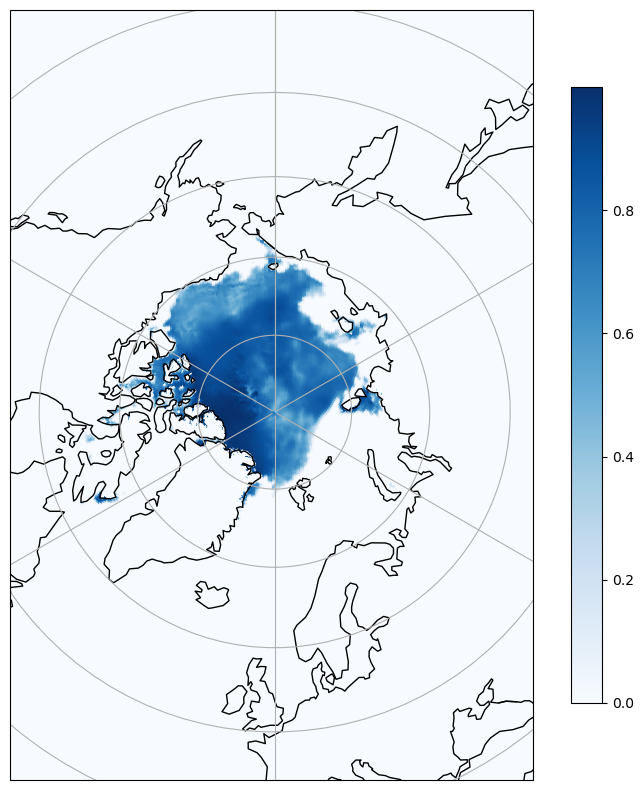

In [16]:
import cartopy.crs as crs
import cartopy.feature as cfeature

fig = plt.figure(figsize=[10, 10])

#ax = fig.add_subplot(1,1,1, projection=crs.Robinson())
crs_epsg=crs.NorthPolarStereo(central_longitude=0)
ax = fig.add_subplot(1,1,1, projection=crs_epsg)

ax.set_extent([-3850000.0, 3750000.0, -5350000, 5850000.0],crs_epsg)

ax.add_feature(cfeature.COASTLINE)
ax.gridlines()

cs = plt.scatter(x=ds.longitude[::10], y=ds.latitude.data[::10], c=ds.siconc[::10], cmap="Blues",
            s=1,
            transform=crs.PlateCarree())

fig.colorbar(cs, ax=ax, location='right', shrink =0.8)
plt.show()